# Deep Learning Image Search dengan CLIP

## 1. Setup Path Project

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Coolyeah/Smstr 6/PACD/Project/cbir-image-search-engine')

## 2. Import Modul Deep Embedding

In [2]:
from src.cbir.deep_embedding import (
    DEFAULT_CLIP_MODEL,
    build_and_save_deep_embedding_index,
    evaluate_deep_embedding_index_file,
    search_deep_embedding_index_file,
)
from src.cbir.visualization import show_search_results

DEFAULT_CLIP_MODEL

'openai/clip-vit-base-patch32'

## 3. Konfigurasi Dataset dan Index

In [3]:
IMAGE_DIR = PROJECT_ROOT / "data" / "images"
INDEX_PATH = PROJECT_ROOT / "models" / "index-clip.pkl"
TOP_K = 10
BATCH_SIZE = 16
DEVICE = "auto"

IMAGE_DIR, INDEX_PATH

(WindowsPath('d:/Coolyeah/Smstr 6/PACD/Project/cbir-image-search-engine/data/images'),
 WindowsPath('d:/Coolyeah/Smstr 6/PACD/Project/cbir-image-search-engine/models/index-clip.pkl'))

## 4. Build Deep Embedding Index

In [4]:
index = build_and_save_deep_embedding_index(
    image_dir=IMAGE_DIR,
    index_path=INDEX_PATH,
    model_name=DEFAULT_CLIP_MODEL,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    verbose=True,
)

print("Indexed images:", len(index.image_paths))
print("Embedding shape:", index.embeddings.shape)
print("Build seconds:", round(index.build_seconds, 2))

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 3789.77it/s]


Model: openai/clip-vit-base-patch32
Device: cpu
Images: 159
Indexed images: 159
Embedding shape: (159, 768)
Build seconds: 64.09


## 5. Evaluasi Precision@10

In [5]:
summary = evaluate_deep_embedding_index_file(
    index_path=INDEX_PATH,
    top_k=TOP_K,
    device=DEVICE,
)

print("Evaluated queries:", summary.query_count)
print(f"Mean precision@{summary.top_k}:", round(summary.mean_precision, 4))

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5993.63it/s]


Evaluated queries: 159
Mean precision@10: 1.0


## 6. Test Query Satu Gambar

In [6]:
QUERY_IMAGE = IMAGE_DIR / "Borobudur-Temple" / "Borobudur.jpg"

response = search_deep_embedding_index_file(
    query_image_path=QUERY_IMAGE,
    index_path=INDEX_PATH,
    top_k=TOP_K,
    device=DEVICE,
)

print("Query seconds:", round(response.query_seconds, 4))
for position, result in enumerate(response.results, start=1):
    print(f"{position:02d}. distance={result.distance:.6f} | {result.image_path}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11369.23it/s]


Query seconds: 6.8196
01. distance=0.000000 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\Borobudur.jpg
02. distance=0.114552 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\Sunrise seen from the Borobudur, Indonesia.jpg
03. distance=0.136268 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\136867276172584247.jpg
04. distance=0.147427 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\336855247148497574.jpg
05. distance=0.147821 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\Borobudur_ The Biggest Buddhist Temple Visited by….jpg
06. distance=0.149782 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\Borobudur Temple, Indonesia.jpg
07. distance=0.149974 | d:\Coolyeah\Smstr 6\PACD\Project\cbir-image-search-engine\data\images\Borobudur-Temple\Borobud

## 7. Visualisasi Hasil Query

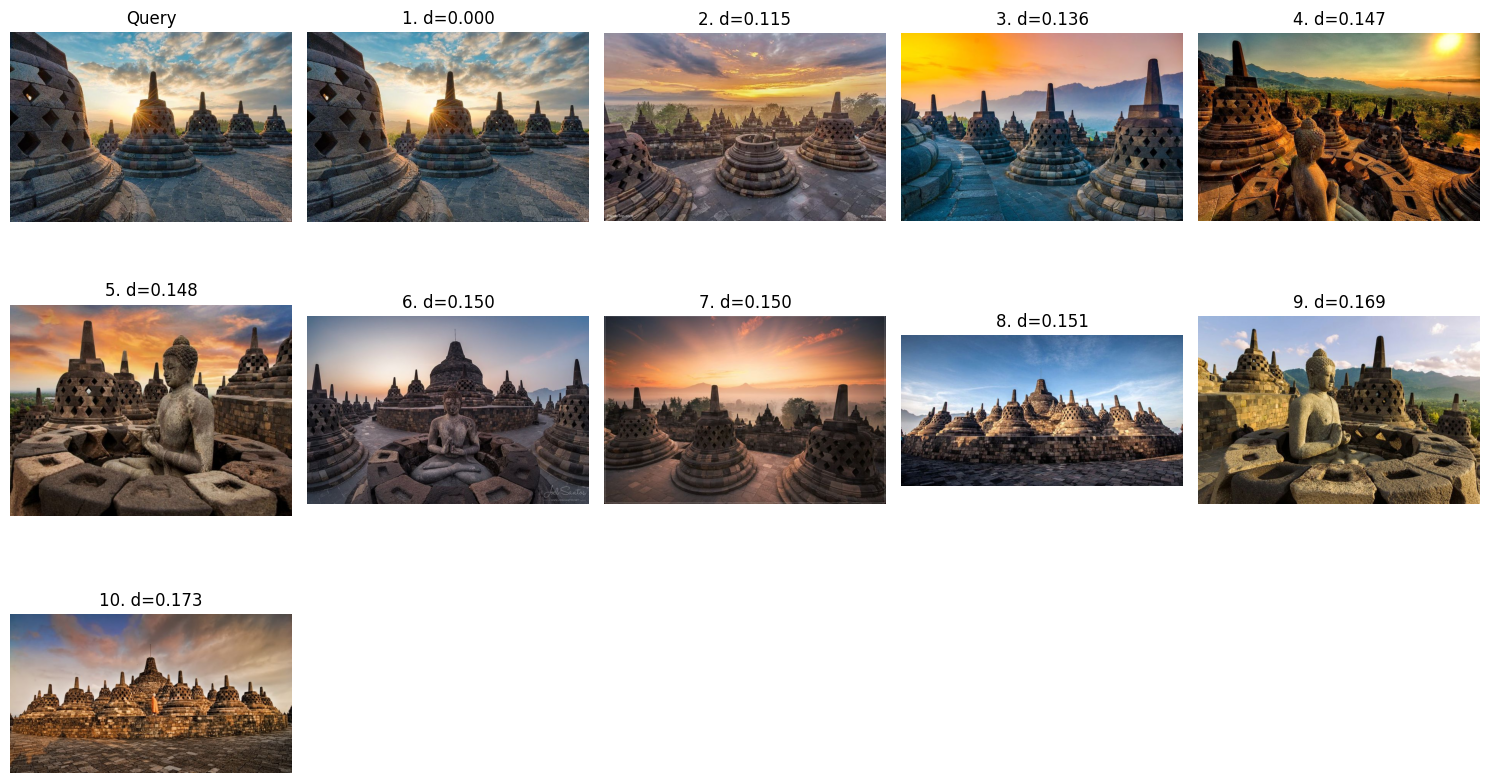

In [7]:
show_search_results(
    query_image_path=QUERY_IMAGE,
    results=response.results,
)